# Klein VAE Experiments

In [1]:
%load_ext autoreload
%autoreload 2

import rootutils
root = rootutils.setup_root(search_from=".", indicator=".project-root", pythonpath=True, cwd=True)

In [11]:
from src.data.uniform_filters_datamodule import UniformFiltersDataModule
from src.models.klein_vae_module import KleinVAEModule
from src.models.components.vae import SimpleVAE

import matplotlib.pyplot as plt

from lightning.pytorch.trainer import Trainer

import random
import numpy as np

from ripser import ripser
from persim import plot_diagrams


Total training examples: 8000


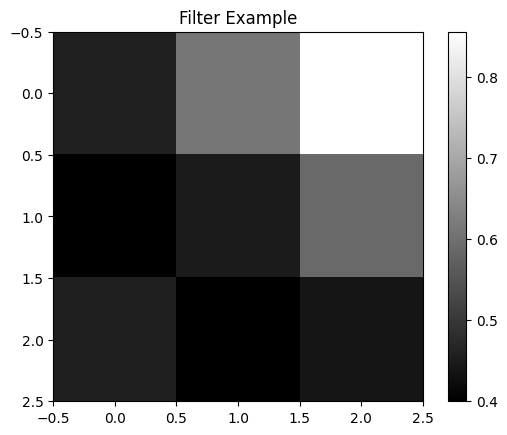

In [3]:
datamodule = UniformFiltersDataModule(num_samples_per_angle=100)
datamodule.setup()
filter_example = datamodule.train_dataloader().dataset[0][0].reshape(3,3)

train_loader = datamodule.train_dataloader()
total_examples = len(train_loader.dataset)
print(f"Total training examples: {total_examples}")

plt.imshow(filter_example, cmap='gray')
plt.colorbar()
plt.title('Filter Example')
plt.show()

### Testing that samples from `UniformFiltersDataModule` lie on the Klein bottle

In [ ]:
dataset = datamodule.train_dataloader().dataset
indices = random.sample(range(len(dataset)), 500)
batch = np.array([dataset[i][0].numpy() for i in indices])

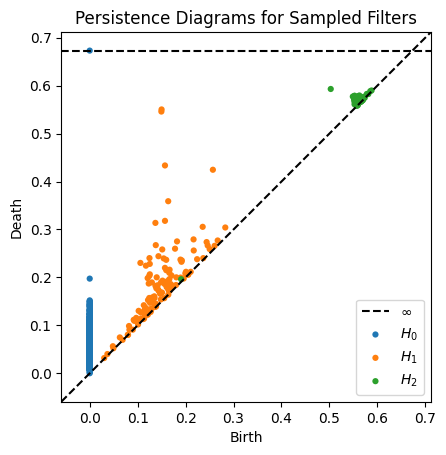

In [ ]:
diagrams = ripser(batch, maxdim=2)['dgms']
plot_diagrams(diagrams, show=True, title='Persistence Diagrams for Sampled Filters')

### Running the model

In [6]:
vae_model = SimpleVAE()
klein_vae_module = KleinVAEModule(model=vae_model, batch_size=64)

#### Checking the filters BEFORE training

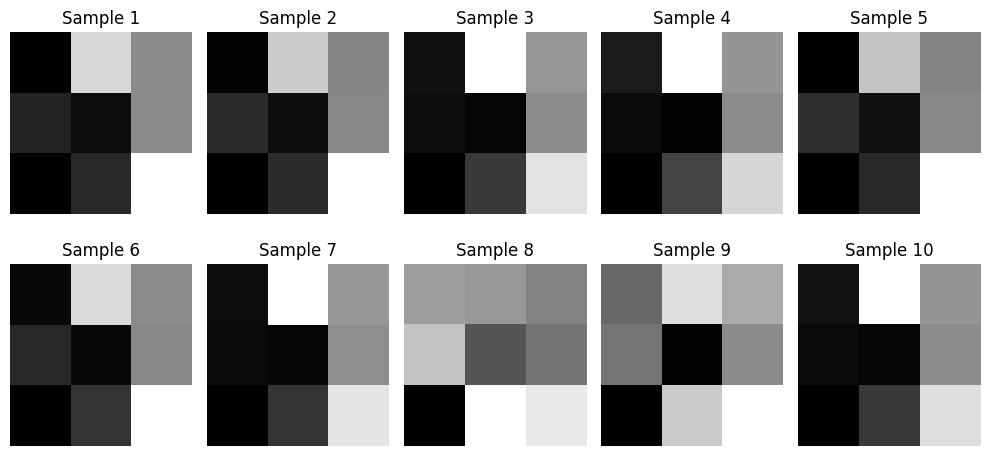

In [41]:
samples = klein_vae_module.sample(num_samples=10)
filters_from_decoder = klein_vae_module.model.decode(samples).reshape(-1, 3, 3)

plt.figure(figsize=(10, 5))
for i, filter_img in enumerate(filters_from_decoder):
    plt.subplot(2, 5, i + 1)
    plt.imshow(filter_img.detach().cpu().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f'Sample {i+1}')
plt.tight_layout()
plt.show()

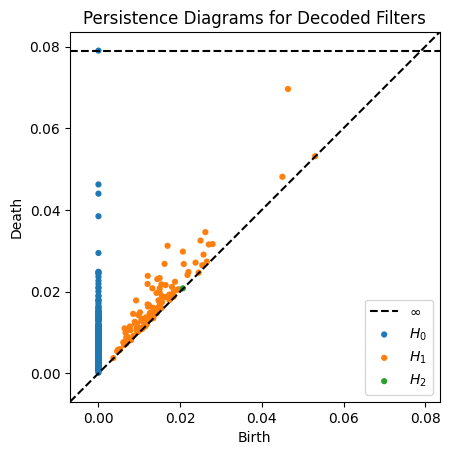

In [42]:
samples = klein_vae_module.sample(num_samples=500)
decoded = klein_vae_module.model.decode(samples).detach().cpu().numpy()
batch = decoded

diagrams = ripser(batch, maxdim=2)['dgms']
plot_diagrams(diagrams, show=True, title='Persistence Diagrams for Decoded Filters')

### Training

In [7]:
trainer = Trainer(devices=1, accelerator="cpu", max_epochs=100, enable_progress_bar=True)
trainer.fit(klein_vae_module, datamodule=datamodule)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | model | SimpleVAE | 6.1 K  | train
--------------------------------------------
6.1 K     Trainable params
0         Non-trainable params
6.1 K     Total params
0.024     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode


/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 99: 100%|██████████| 250/250 [00:01<00:00, 199.29it/s, v_num=16]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 250/250 [00:01<00:00, 198.44it/s, v_num=16]


In [8]:
# Retrieve and display the logged metrics after training
metrics = trainer.callback_metrics
print(metrics)

{'train_loss': tensor(193.2830), 'recon_loss': tensor(191.1506), 'kl_div': tensor(2.1324), 'val_loss': tensor(193.4529), 'val_recon_loss': tensor(191.3764), 'val_kl_div': tensor(2.0765)}


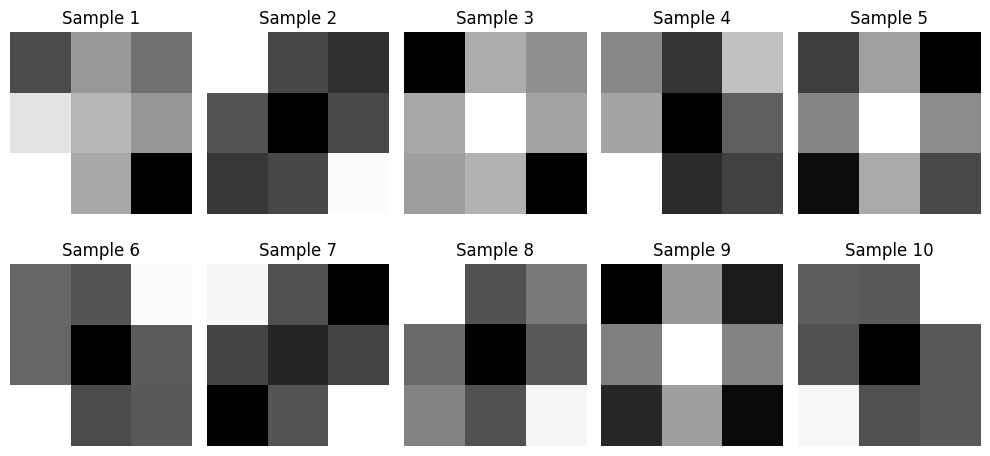

In [9]:
samples = klein_vae_module.sample(num_samples=10)
filters_from_decoder = klein_vae_module.model.decode(samples).reshape(-1, 3, 3)

plt.figure(figsize=(10, 5))
for i, filter_img in enumerate(filters_from_decoder):
    plt.subplot(2, 5, i + 1)
    plt.imshow(filter_img.detach().cpu().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f'Sample {i+1}')
plt.tight_layout()
plt.show()

### Testing that decoded samples also lie on the Klein bottle

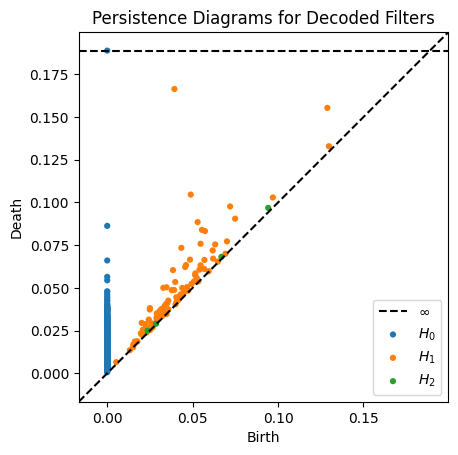

In [12]:
samples = klein_vae_module.sample(num_samples=500)
decoded = klein_vae_module.model.decode(samples).detach().cpu().numpy()
batch = decoded

diagrams = ripser(batch, maxdim=2)['dgms']
plot_diagrams(diagrams, show=True, title='Persistence Diagrams for Decoded Filters')

### Multiple centers

In [31]:
from src.data.multiclass_filters_datamodule import MulticlassFiltersDataModule

Total training examples: 648000


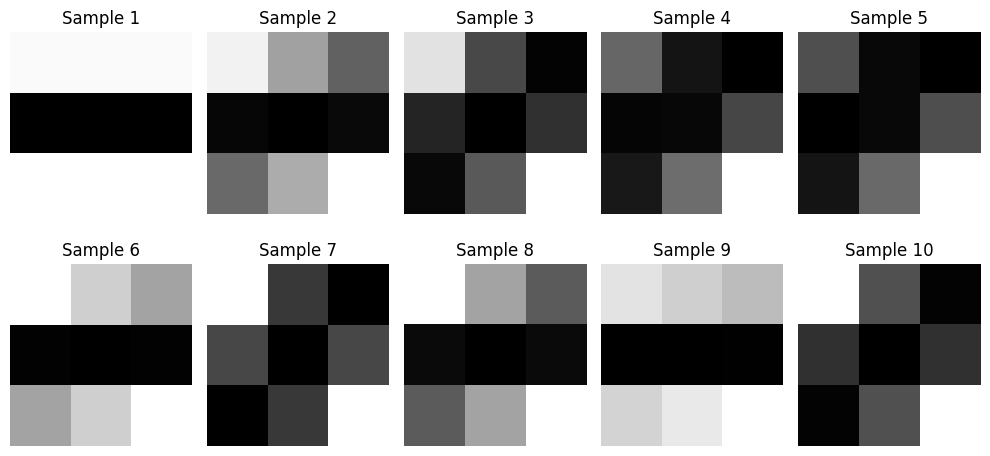

In [ ]:
multiclass_datamodule = MulticlassFiltersDataModule(num_samples_per_angle=100)
multiclass_datamodule.setup()
multiclass_datamodule.train_dataloader().dataset[640][0]

total_examples = len(multiclass_datamodule.train_dataloader().dataset)
print(f"Total training examples: {total_examples}")

indices = random.sample(range(total_examples), 10)
filters = [multiclass_datamodule.train_dataloader().dataset[i][0].reshape(3, 3) for i in indices]

plt.figure(figsize=(10, 5))
for i, filter_img in enumerate(filters):
    plt.subplot(2, 5, i + 1)
    plt.imshow(filter_img.detach().cpu().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f'Sample {i+1}')
plt.tight_layout()
plt.show()

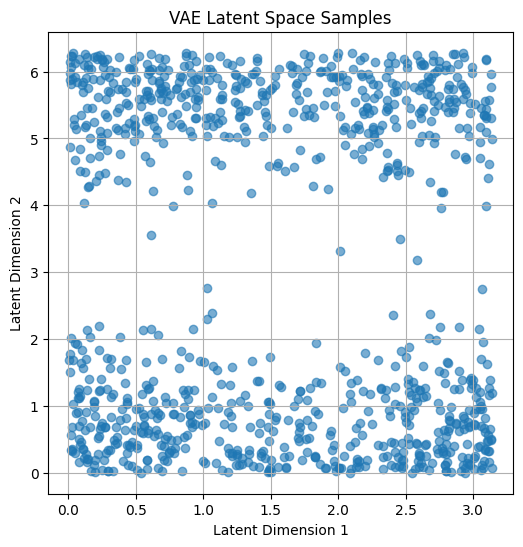

In [35]:
# Scatter plot of latent coordinates in 2D
try:
    coords = multiclass_datamodule.coordinates.detach().cpu().numpy()
except AttributeError:
    coords = samples  # assume it's already a NumPy array

plt.figure(figsize=(6, 6))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.6)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('VAE Latent Space Samples')
plt.grid(True)
plt.show()